In [1]:
import os
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import PyComplexHeatmap as pch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
class MidpointNormalize(Normalize):
    """
    Normalize the colorbar so that 0 is at the center (white).
    Works for any matplotlib version.
    """
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Avoid modifying original data
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))



In [2]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [3]:
df_DAR.Direction.value_counts()

Up      201010
Down    133127
Name: Direction, dtype: int64

In [4]:
df_ion = pd.read_excel('/data2st2/junyi/output/all_iron_channel/gene_list_all_iron_channel.xlsx')

In [5]:
cat_order = df_ion.Category.unique().tolist()

In [6]:
df_DAR_ion=df_DAR.merge(df_ion.loc[:, ['Gene','Category']], left_on='gene_name', right_on='Gene', how='inner')

In [7]:
df_DAR.Neurotransmitter.value_counts()

Glut    244374
GABA     66075
NN       23688
Name: Neurotransmitter, dtype: int64

In [8]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Subclass,Sex,Region Subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100456562-100457063,-0.006031,Down,Glut,chr10:100456562-100457063,2.751694e-02
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112328.1,chr10:100642797-100643298,-0.014478,Down,Glut,chr10:100642797-100643298,1.490774e-02
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112713.1,chr10:10107158-10107659,0.030881,Up,Glut,chr10:10107158-10107659,2.347109e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000018909.15,chr7:99535252-99535753,0.001785,Up,GABA,chr7:99535252-99535753,1.977464e-02
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032803.15,chr9:103365644-103366145,0.028069,Up,GABA,chr9:103365644-103366145,4.904168e-02
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032470.17,chr9:99436435-99436936,-0.054067,Down,GABA,chr9:99436435-99436936,3.488255e-02
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,PFC_Sst_Chodl_GABA,M,PFC_Sst_Chodl_GABA,ENSMUSG00000021368.15,chr13:43171217-43171718,NaN,Down,GABA,chr13:43171217-43171718,1.842970e-02


In [9]:
def show_stacked_barplot(df_DAR,column_status="primary_region"):
    df = df_DAR.copy()
    # Aggregate
    up_df = df[df["status"] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df["status"] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)

    # Down values become negative
    down_df = -down_df

    # Unified color palette for primary regions
    categories = up_df.columns
    cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.
    colors = {cat: cmap(i) for i, cat in enumerate(categories)}


    plt.figure(figsize=(18,8))

    # ----- Plot Up (positive) -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]

    # ----- Plot Down (negative) -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]

    # Formatting
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.title("Unified-Color Up/Down Stacked Barplot of Primary Region per Cell Type")

    # SINGLE legend (only regions)
    handles = [plt.Rectangle((0,0),1,1,color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02,1), loc='upper left', title="Primary Region")

    plt.tight_layout()
    plt.show()


In [10]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Subclass,Sex,Region Subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100456562-100457063,-0.006031,Down,Glut,chr10:100456562-100457063,2.751694e-02
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112328.1,chr10:100642797-100643298,-0.014478,Down,Glut,chr10:100642797-100643298,1.490774e-02
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112713.1,chr10:10107158-10107659,0.030881,Up,Glut,chr10:10107158-10107659,2.347109e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000018909.15,chr7:99535252-99535753,0.001785,Up,GABA,chr7:99535252-99535753,1.977464e-02
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032803.15,chr9:103365644-103366145,0.028069,Up,GABA,chr9:103365644-103366145,4.904168e-02
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032470.17,chr9:99436435-99436936,-0.054067,Down,GABA,chr9:99436435-99436936,3.488255e-02
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,PFC_Sst_Chodl_GABA,M,PFC_Sst_Chodl_GABA,ENSMUSG00000021368.15,chr13:43171217-43171718,NaN,Down,GABA,chr13:43171217-43171718,1.842970e-02


/tmp/ipykernel_2579091/4080114417.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.


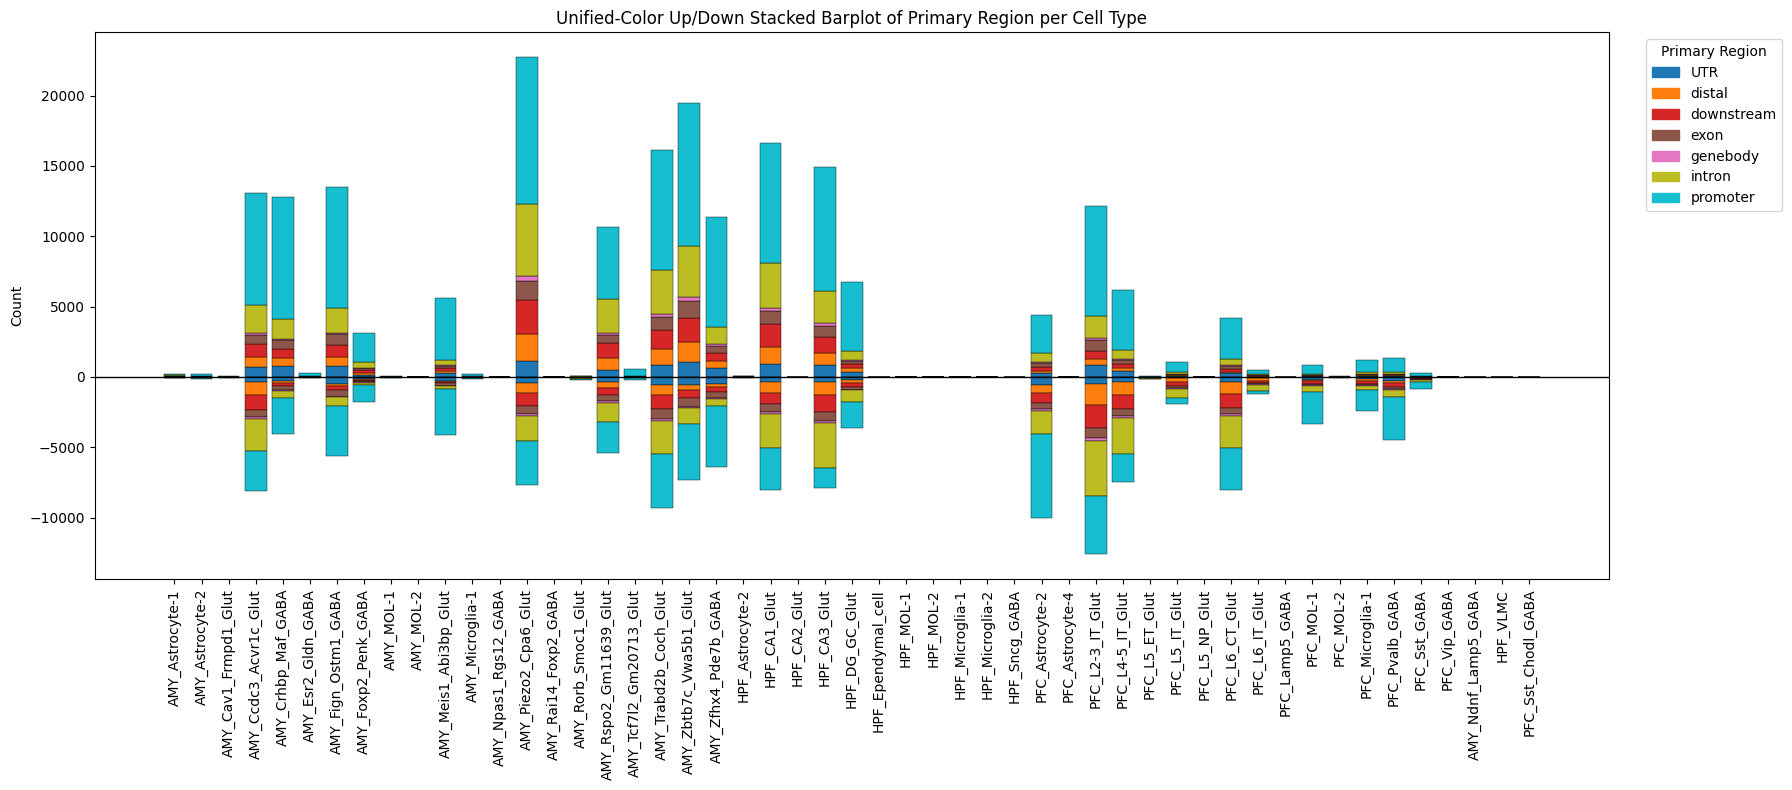

/tmp/ipykernel_2579091/4080114417.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.


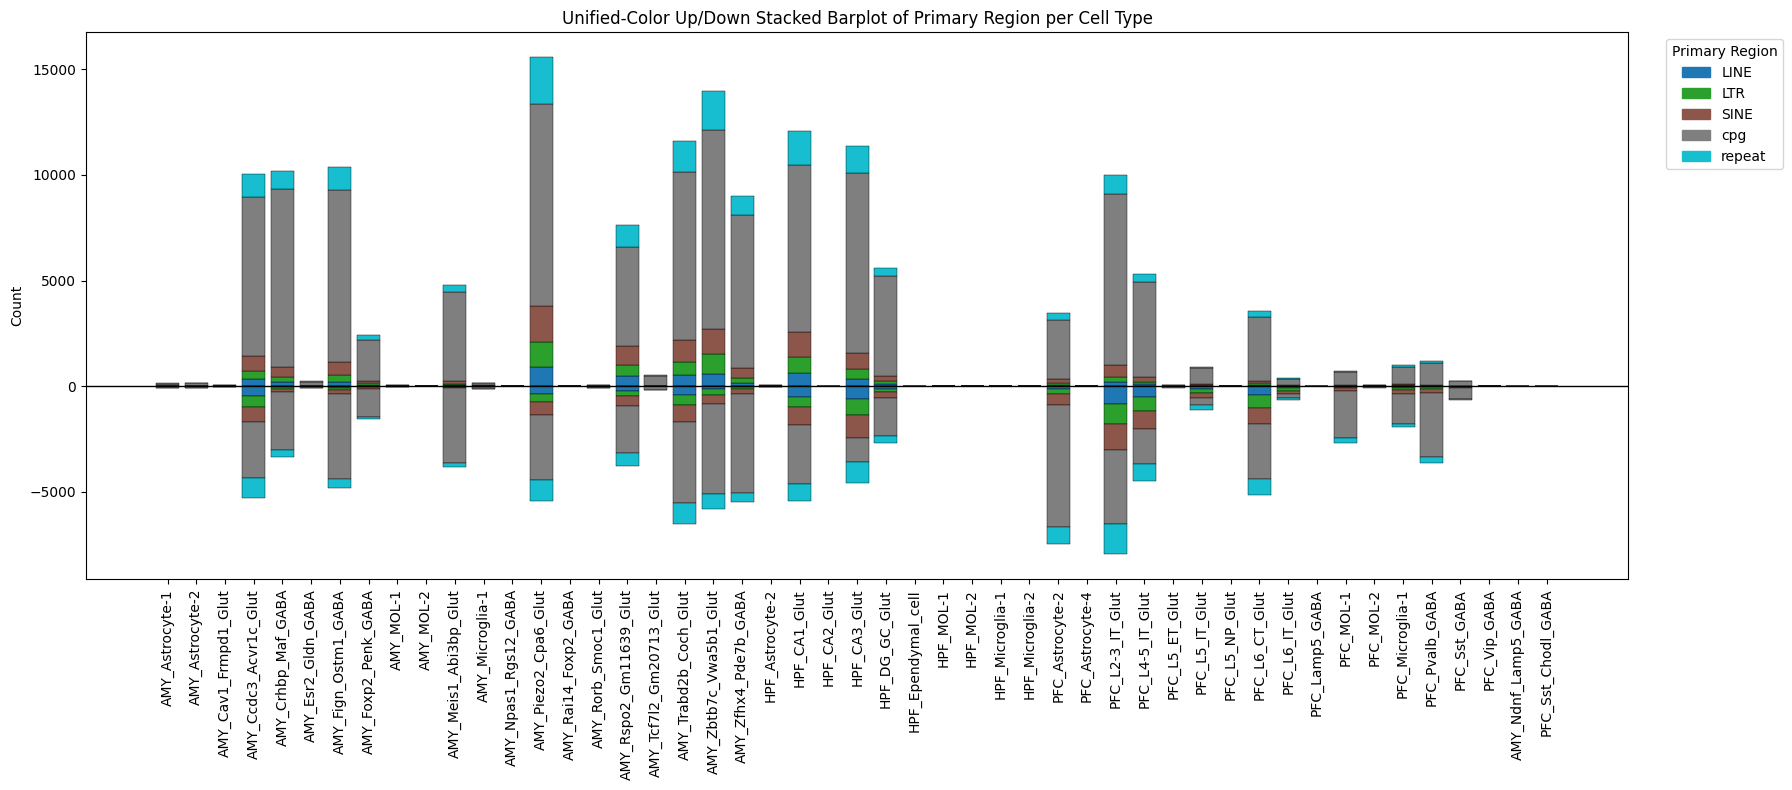

/tmp/ipykernel_2579091/4080114417.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.


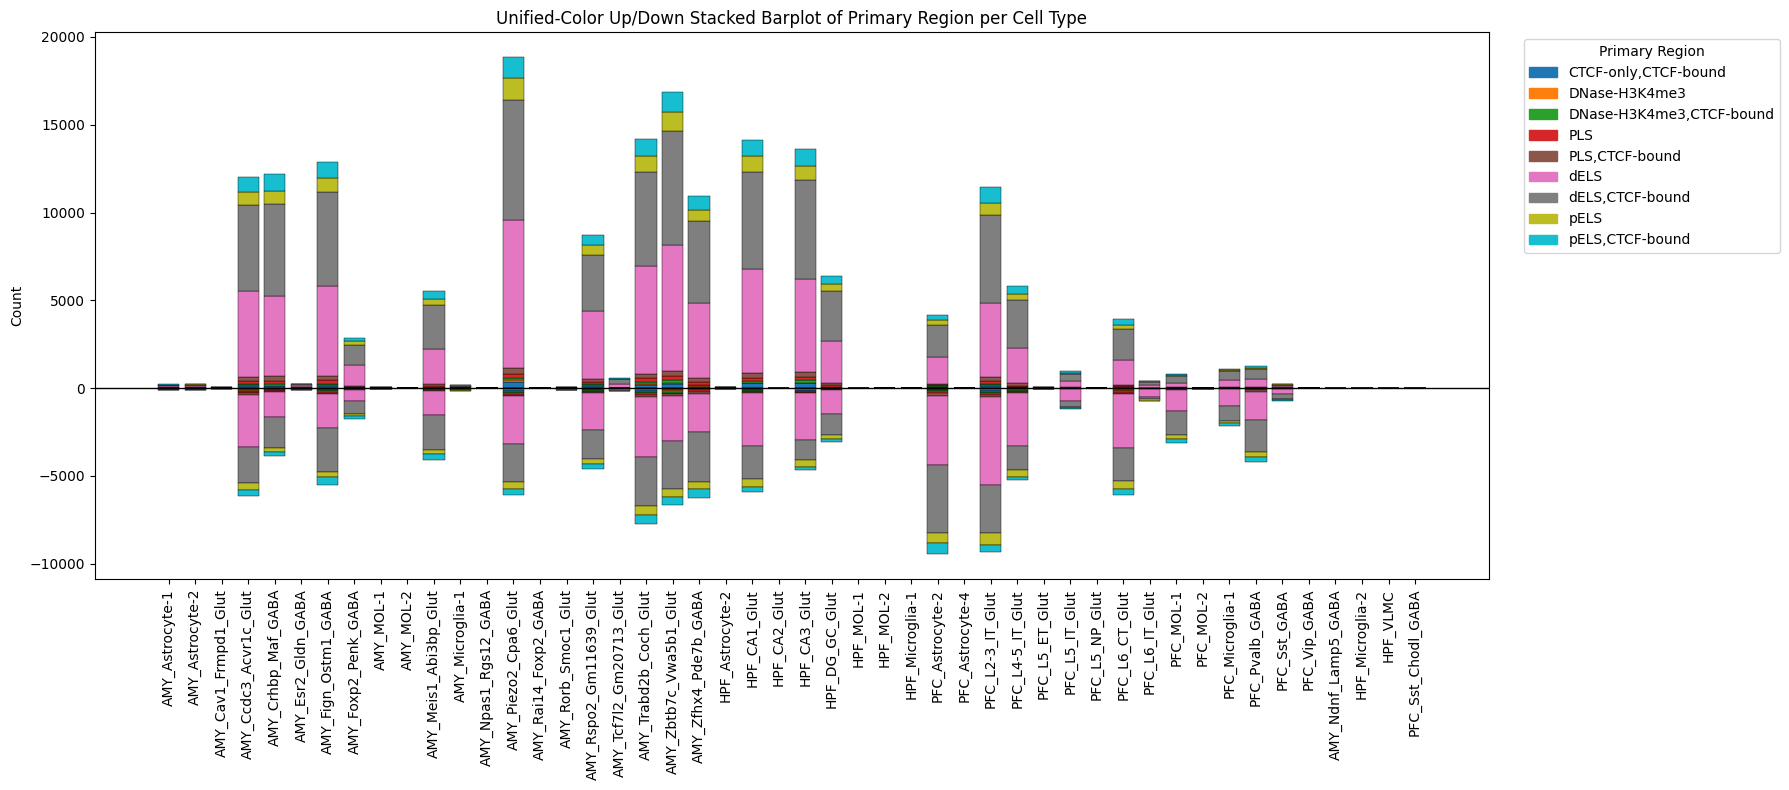

In [11]:
for columns in ["primary_region","secondary_region","encodeCCRE"]:
    show_stacked_barplot(df_DAR,column_status=columns)

In [44]:


# 你给的 Region 颜色
region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    # "TH":  "#863220",
    # "STR": "#8A60AA",
    # "HY":  "#D88A91",
    "PFC": "#F57E20",
    # "MB":  "#E0B362",
    # "iCTX": "#82C341",
}

# 自己定义一个神经递质颜色（示例，可按你实际情况改）
nt_colors = {
    "Glut": "#FFC000",
    "GABA": "#00B050",
    # "Dopa": "#ff7f0e",
    # "Hist": "#aa40fc",
    # "Chol": "#1f77b4",
    # "Sero": "#e377c2",
    "NN":   "#8c564b",
}

# 行 Category 颜色（示例，可按自己分类改）
# category_colors = {
#     "Module1": "#1f77b4",
#     "Module2": "#ff7f0e",
#     "Module3": "#2ca02c",
# }


def draw_complex_heatmap(df, value_col="nlogp",index='Gene_y'):
    """
    df: 包含 Gene_y, Region subclass, Region, Neurotransmitter, Category, value_col
    value_col: 用来画热图的数值列名，比如 'nlogp'、'logFC'、表达量等
    """

    # 1. 生成矩阵：行 = Gene_y，列 = Region subclass
    mat = (
        df.pivot_table(
            index=index,
            columns="Region Subclass",
            values=value_col,
            aggfunc=lambda x: x.fillna(0)[np.abs(x.fillna(0)).idxmax()]   # 有重复时取平均，你也可以改成 'max'
        )
    )

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)

    #mat.clip(lower=-10, upper=10, inplace=True)  # 可选：裁剪极端值，防止颜色失真

    # 2. 准备列注释：Region + Neurotransmitter
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates(subset="Region Subclass")
        .set_index("Region Subclass")
    )
    col_meta = col_meta.loc[mat.columns]

    # 让列按 Region 排序（同一脑区聚在一起）
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]

    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # 3. 准备行注释：Category
    row_meta = (
        df[[index, "Category"]]
        .drop_duplicates(subset=index)
        .set_index(index)
    )
    row_meta = row_meta.loc[mat.index]
    category = row_meta["Category"]

    # 4. 列注释（顶端）：Region + Neurotransmitter
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )

    # 5. 行注释（左侧）：Category
    row_ha = pch.HeatmapAnnotation(
        Category=pch.anno_simple(category, add_text=False),
        axis=0
    )

    # 6. 画图
    #   这里用一个对称的渐变色图：蓝 - 白 - 橙，你可以自由改 cmap
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )

    plt.figure(figsize=(10, 14))
    norm = MidpointNormalize(
        vmin=np.nanmin(mat.values),
        vmax=np.nanmax(mat.values),
        midpoint=0     # ← center at zero
    )

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,      # 列注释：Region + NT
        left_annotation=row_ha,     # 行注释：Category
        col_split=region,           # 列按 Region 分块
        row_split=category,         # 行按 Category 分块
        row_cluster=True,
        row_dendrogram=False,
        col_cluster=True,
        col_dendrogram=True,
        show_rownames=True,
        show_colnames=True,
        col_split_order=['AMY','PFC','HPF'],  # 按这个顺序排脑区,
        #row_split_order=cat_order,  # 行分类顺序按出现顺序
        cmap=cmap,
        norm=norm,              # ← ★★ center at ZERO ★★

        label=value_col,
        rasterized=True
    )

    # 可选：把行/列名字体调小，防止太密
    if getattr(cm, "ax_row_names", None) is not None:
        for txt in cm.ax_row_names.texts:
            txt.set_fontsize(3)
            txt.set_rotation(0)

    if getattr(cm, "ax_col_names", None) is not None:
        for txt in cm.ax_col_names.texts:
            txt.set_fontsize(7)
            txt.set_rotation(90)

    plt.subplots_adjust(left=0.3, bottom=0.25)
    plt.show()

    return cm


In [13]:
df_DAR_ion.Neurotransmitter.value_counts()

Glut    3939
GABA     846
NN       171
Name: Neurotransmitter, dtype: int64

In [14]:
df_DAR_ion["nlogp"] = -np.log10(df_DAR_ion["FDR"] + 1e-300) * np.sign(df_DAR_ion["log2FC"])
df_DAR_ion["nlogp"] = df_DAR_ion["nlogp"].clip(-20, 20)

In [15]:
df_DAR_ion.status.value_counts()

Up      2560
Down    2396
Name: status, dtype: int64

(-0.1, 0.1)

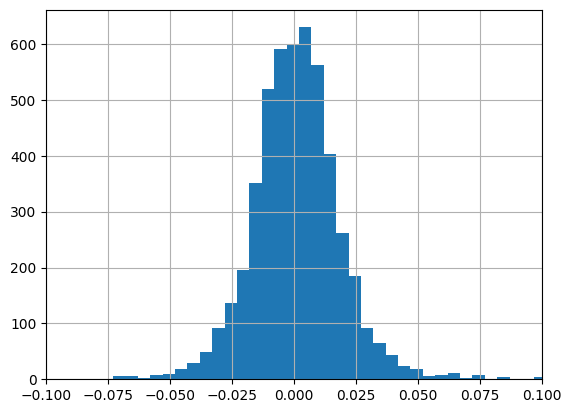

In [16]:
df_DAR_ion.coef.hist(bins=50)
plt.xlim(-0.1, 0.1)

In [17]:
df_DAR_ion

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Ensemble,Gene_x,log2FC,Direction,Neurotransmitter,Gene_name,FDR,Gene_y,Category,nlogp
0,chr10:112360660-112361161,2.745604e-02,-0.005947,0.005487,-0.017381,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,4.544588e-02,...,ENSMUSG00000035681.7,chr10:112360660-112361161,-0.005947,Down,Glut,chr10:112360660-112361161,4.544588e-02,Kcnc2,Voltage-gated potassium ion,-1.342505
1,chr10:112263403-112263904,9.475666e-03,0.005477,0.014903,-0.003950,1.000000,HPF_CA1_Glut,HPF,HPF_CA1_Glut,1.377770e-02,...,ENSMUSG00000035681.7,chr10:112263403-112263904,0.005477,Up,Glut,chr10:112263403-112263904,1.377770e-02,Kcnc2,Voltage-gated potassium ion,1.860823
2,chr10:112315063-112315564,4.521827e-03,0.000102,0.010704,-0.010499,1.000000,HPF_CA1_Glut,HPF,HPF_CA1_Glut,7.317077e-03,...,ENSMUSG00000035681.7,chr10:112315063-112315564,0.000102,Up,Glut,chr10:112315063-112315564,7.317077e-03,Kcnc2,Voltage-gated potassium ion,2.135662
3,chr10:112315063-112315564,2.156126e-07,-0.007470,0.006428,-0.021368,0.005977,AMY_Piezo2_Cpa6_Glut,AMY,AMY_Piezo2_Cpa6_Glut,9.689635e-07,...,ENSMUSG00000035681.7,chr10:112315063-112315564,-0.007470,Down,Glut,chr10:112315063-112315564,9.689635e-07,Kcnc2,Voltage-gated potassium ion,-6.013693
4,chr10:112400734-112401235,1.165565e-02,0.001674,0.013716,-0.010368,1.000000,AMY_Piezo2_Cpa6_Glut,AMY,AMY_Piezo2_Cpa6_Glut,1.281974e-02,...,ENSMUSG00000035681.7,chr10:112400734-112401235,0.001674,Up,Glut,chr10:112400734-112401235,1.281974e-02,Kcnc2,Voltage-gated potassium ion,1.892121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4951,chr2:63184365-63184866,1.447641e-03,0.007094,0.015186,-0.000998,1.000000,PFC_L4-5_IT_Glut,PFC,PFC_L4.5_IT_Glut,5.671172e-03,...,ENSMUSG00000059742.10,chr2:63184365-63184866,0.007094,Up,Glut,chr2:63184365-63184866,5.671172e-03,Kcnh7,Voltage-gated potassium ion,2.246327
4952,chr2:62878704-62879205,6.078976e-07,0.020702,0.033467,0.007938,0.014251,AMY_Zbtb7c_Vwa5b1_Glut,AMY,AMY_Zbtb7c_Vwa5b1_Glut,1.601518e-06,...,ENSMUSG00000059742.10,chr2:62878704-62879205,0.020702,Up,Glut,chr2:62878704-62879205,1.601518e-06,Kcnh7,Voltage-gated potassium ion,5.795468
4953,chr2:63117210-63117711,5.660206e-04,-0.004062,0.009058,-0.017183,1.000000,AMY_Zbtb7c_Vwa5b1_Glut,AMY,AMY_Zbtb7c_Vwa5b1_Glut,7.006294e-04,...,ENSMUSG00000059742.10,chr2:63117210-63117711,-0.004062,Down,Glut,chr2:63117210-63117711,7.006294e-04,Kcnh7,Voltage-gated potassium ion,-3.154512
4954,chr2:66346118-66346619,2.837007e-03,-0.010261,-0.004077,-0.016444,1.000000,PFC_L2-3_IT_Glut,PFC,PFC_L2.3_IT_Glut,4.805939e-03,...,ENSMUSG00000064329.13,chr2:66346118-66346619,-0.010261,Down,Glut,chr2:66346118-66346619,4.805939e-03,Scn1a,Sodium ion,-2.318222


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 71.79166666666667 mm


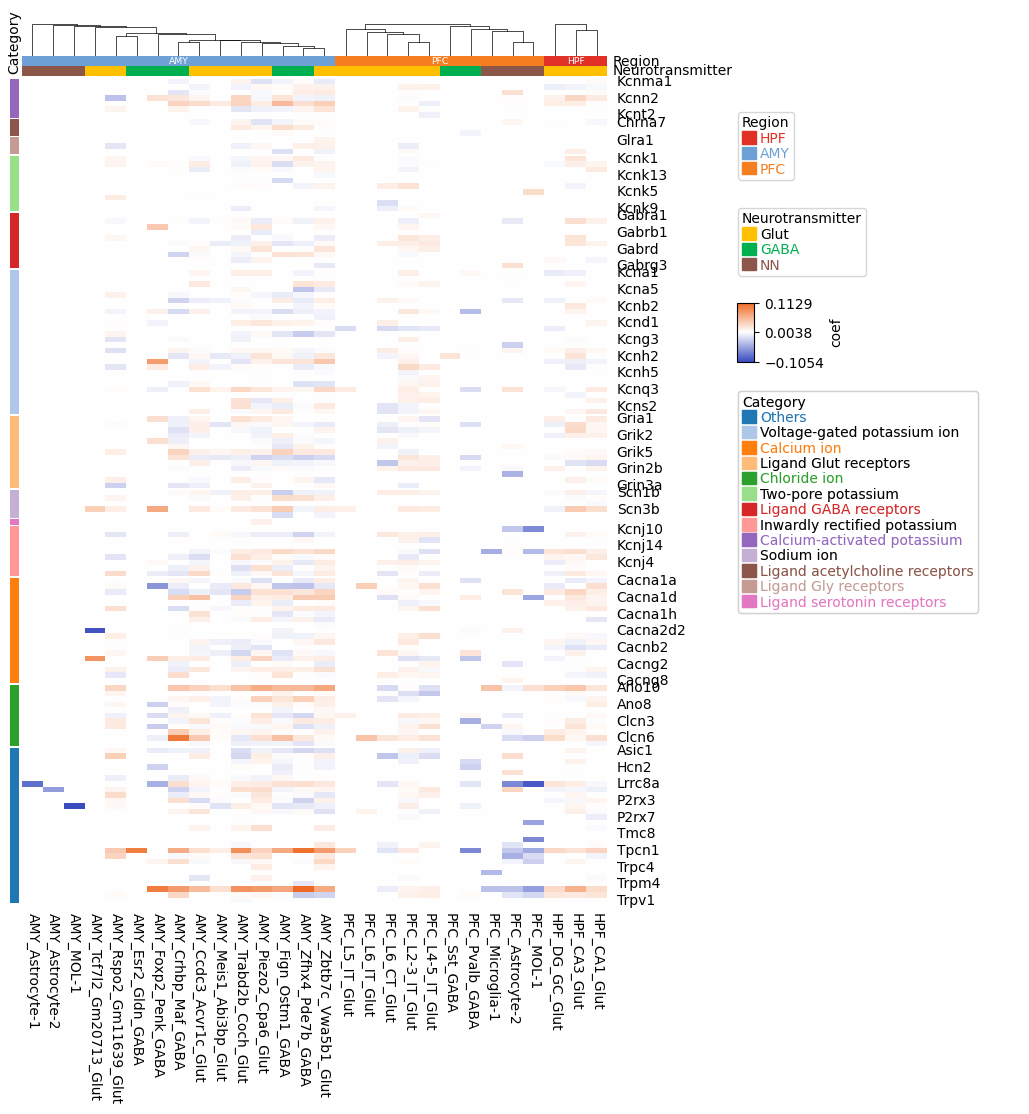

In [18]:
cm = draw_complex_heatmap(df_DAR_ion[df_DAR_ion.primary_region=="promoter"], value_col="coef")


In [21]:
df_tobias_fc1=pd.read_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all_fc1.csv',index_col=0)

In [22]:
df_ion

,Gene,Category,中文类别,中文名称 (Chinese name)
0,Cacna1c,Calcium ion,钙离子通道,电压门控钙离子通道-L型（Cav1.2）
1,Cacna1d,Calcium ion,钙离子通道,电压门控钙离子通道-L型（Cav1.3）
2,Cacna1f,Calcium ion,钙离子通道,电压门控钙离子通道-L型（Cav1.4）
3,Cacna1b,Calcium ion,钙离子通道,电压门控钙离子通道-N型（Cav2.2）
4,Cacna1a,Calcium ion,钙离子通道,电压门控钙离子通道-P/Q型（Cav2.1）
...,...,...,...,...
252,Asic1,Others,Others,质子门控阳离子通道-ASIC1
253,Asic2,Others,Others,质子门控阳离子通道-ASIC2
254,Asic3,Others,Others,质子门控阳离子通道-ASIC3
255,Asic4,Others,Others,质子门控阳离子通道-ASIC4


In [25]:
df_tobias_fc1_ion = df_tobias_fc1[df_tobias_fc1.gene_name.isin(df_ion.Gene)]

In [28]:
df_tobias_fc1_ion['Region'] = df_tobias_fc1_ion['Region Subclass'].str[:3]

/tmp/ipykernel_2579091/578622404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tobias_fc1_ion['Region'] = df_tobias_fc1_ion['Region Subclass'].str[:3]


In [30]:
df_tobias_fc1_ion['Neurotransmitter'] = df_tobias_fc1_ion['Region Subclass'].map(
    lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN')
)

/tmp/ipykernel_2579091/3961059608.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tobias_fc1_ion['Neurotransmitter'] = df_tobias_fc1_ion['Region Subclass'].map(


In [33]:
df_tobias_fc1_ion = df_tobias_fc1_ion[df_tobias_fc1_ion.distance.abs()<50000]

In [41]:
df_tobias_fc1_ion=df_tobias_fc1_ion.merge(df_ion.loc[:, ['Gene','Category']], left_on='gene_name', right_on='Gene', how='inner')

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexH

Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 71.79166666666667 mm


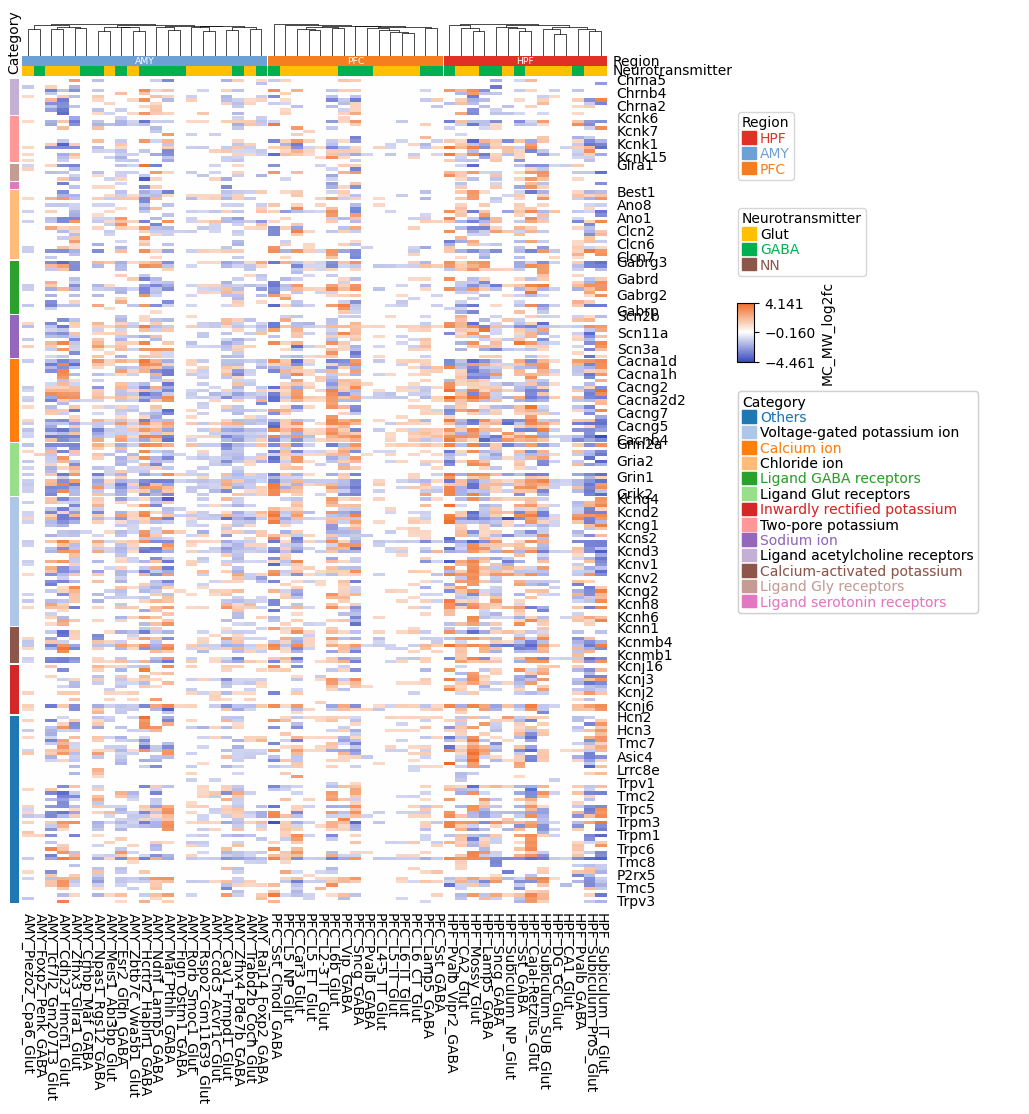

In [45]:
cm = draw_complex_heatmap(df_tobias_fc1_ion[df_tobias_fc1_ion.Neurotransmitter!='NN'],index='gene_name', value_col="MC_MW_log2fc")


In [106]:
df_DAR_TF= pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_with_TFs.csv')

In [107]:
df_DAR_TF["TFs"] = df_DAR_TF["TFs"].replace("Missing value", None)

# 1. 按 "/" 分割 TF 列
df_DAR_TF["TFs"] = df_DAR_TF["TFs"].str.split("/")

# 2. explode 展开为多行（melt）
df_long = df_DAR_TF.explode("TFs").reset_index(drop=True)

In [108]:
df_long_distinct = df_long.drop_duplicates(subset=["names","Region Subclass Direction", "TFs"])

In [109]:
df_long_distinct_UP = df_long_distinct[df_long_distinct["Direction"]=="UP"]

In [110]:
df_long_distinct_groupd= df_long_distinct.groupby(['Region Subclass','Direction', 'TFs']).nunique()['names'].reset_index()

In [111]:
df_long_distinct_groupd['Region'] = df_long_distinct_groupd['Region Subclass'].str.split('_').str[0]

In [112]:
dic_ctnt = dict(zip(df_DAR_ion['Region Subclass'], df_DAR_ion['Neurotransmitter']))

In [113]:
dic_ctnt

{'HPF_CA3_Glut': 'Glut',
 'HPF_CA1_Glut': 'Glut',
 'AMY_Piezo2_Cpa6_Glut': 'Glut',
 'AMY_Trabd2b_Coch_Glut': 'Glut',
 'PFC_L2-3_IT_Glut': 'Glut',
 'AMY_Crhbp_Maf_GABA': 'GABA',
 'AMY_Ccdc3_Acvr1c_Glut': 'Glut',
 'PFC_L5_IT_Glut': 'Glut',
 'AMY_Zfhx4_Pde7b_GABA': 'GABA',
 'PFC_L6_CT_Glut': 'Glut',
 'AMY_Fign_Ostm1_GABA': 'GABA',
 'HPF_DG_GC_Glut': 'Glut',
 'PFC_L4-5_IT_Glut': 'Glut',
 'AMY_Zbtb7c_Vwa5b1_Glut': 'Glut',
 'AMY_Rspo2_Gm11639_Glut': 'Glut',
 'PFC_MOL-1': 'NN',
 'PFC_Pvalb_GABA': 'GABA',
 'AMY_Foxp2_Penk_GABA': 'GABA',
 'AMY_Meis1_Abi3bp_Glut': 'Glut',
 'PFC_Astrocyte-2': 'NN',
 'PFC_Microglia-1': 'NN',
 'PFC_L6_IT_Glut': 'Glut',
 'PFC_MOL-2': 'NN',
 'AMY_Rorb_Smoc1_Glut': 'Glut',
 'AMY_Cav1_Frmpd1_Glut': 'Glut',
 'AMY_Microglia-1': 'NN',
 'AMY_Esr2_Gldn_GABA': 'GABA',
 'PFC_Sst_GABA': 'GABA',
 'AMY_Astrocyte-2': 'NN',
 'PFC_L5_ET_Glut': 'Glut',
 'AMY_Astrocyte-1': 'NN',
 'AMY_Tcf7l2_Gm20713_Glut': 'Glut',
 'AMY_MOL-1': 'NN'}

In [114]:
df_long_distinct_groupd['Neurotransmitter'] = df_long_distinct_groupd['Region Subclass'].map(dic_ctnt)

In [115]:
df_long_distinct_groupd['count'] = df_long_distinct_groupd['names'] * (df_long_distinct_groupd['Direction']=="Up").map({True:1, False:-1})

In [116]:
df_long_distinct_groupd['Category'] = 'TFs'

In [117]:
df_long_distinct_groupd = df_long_distinct_groupd.dropna()

In [118]:
df_sn_import = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)

In [119]:
df_long_distinct_groupd_selected = df_long_distinct_groupd[df_long_distinct_groupd['TFs'].isin(df_sn_import[0].values)]

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


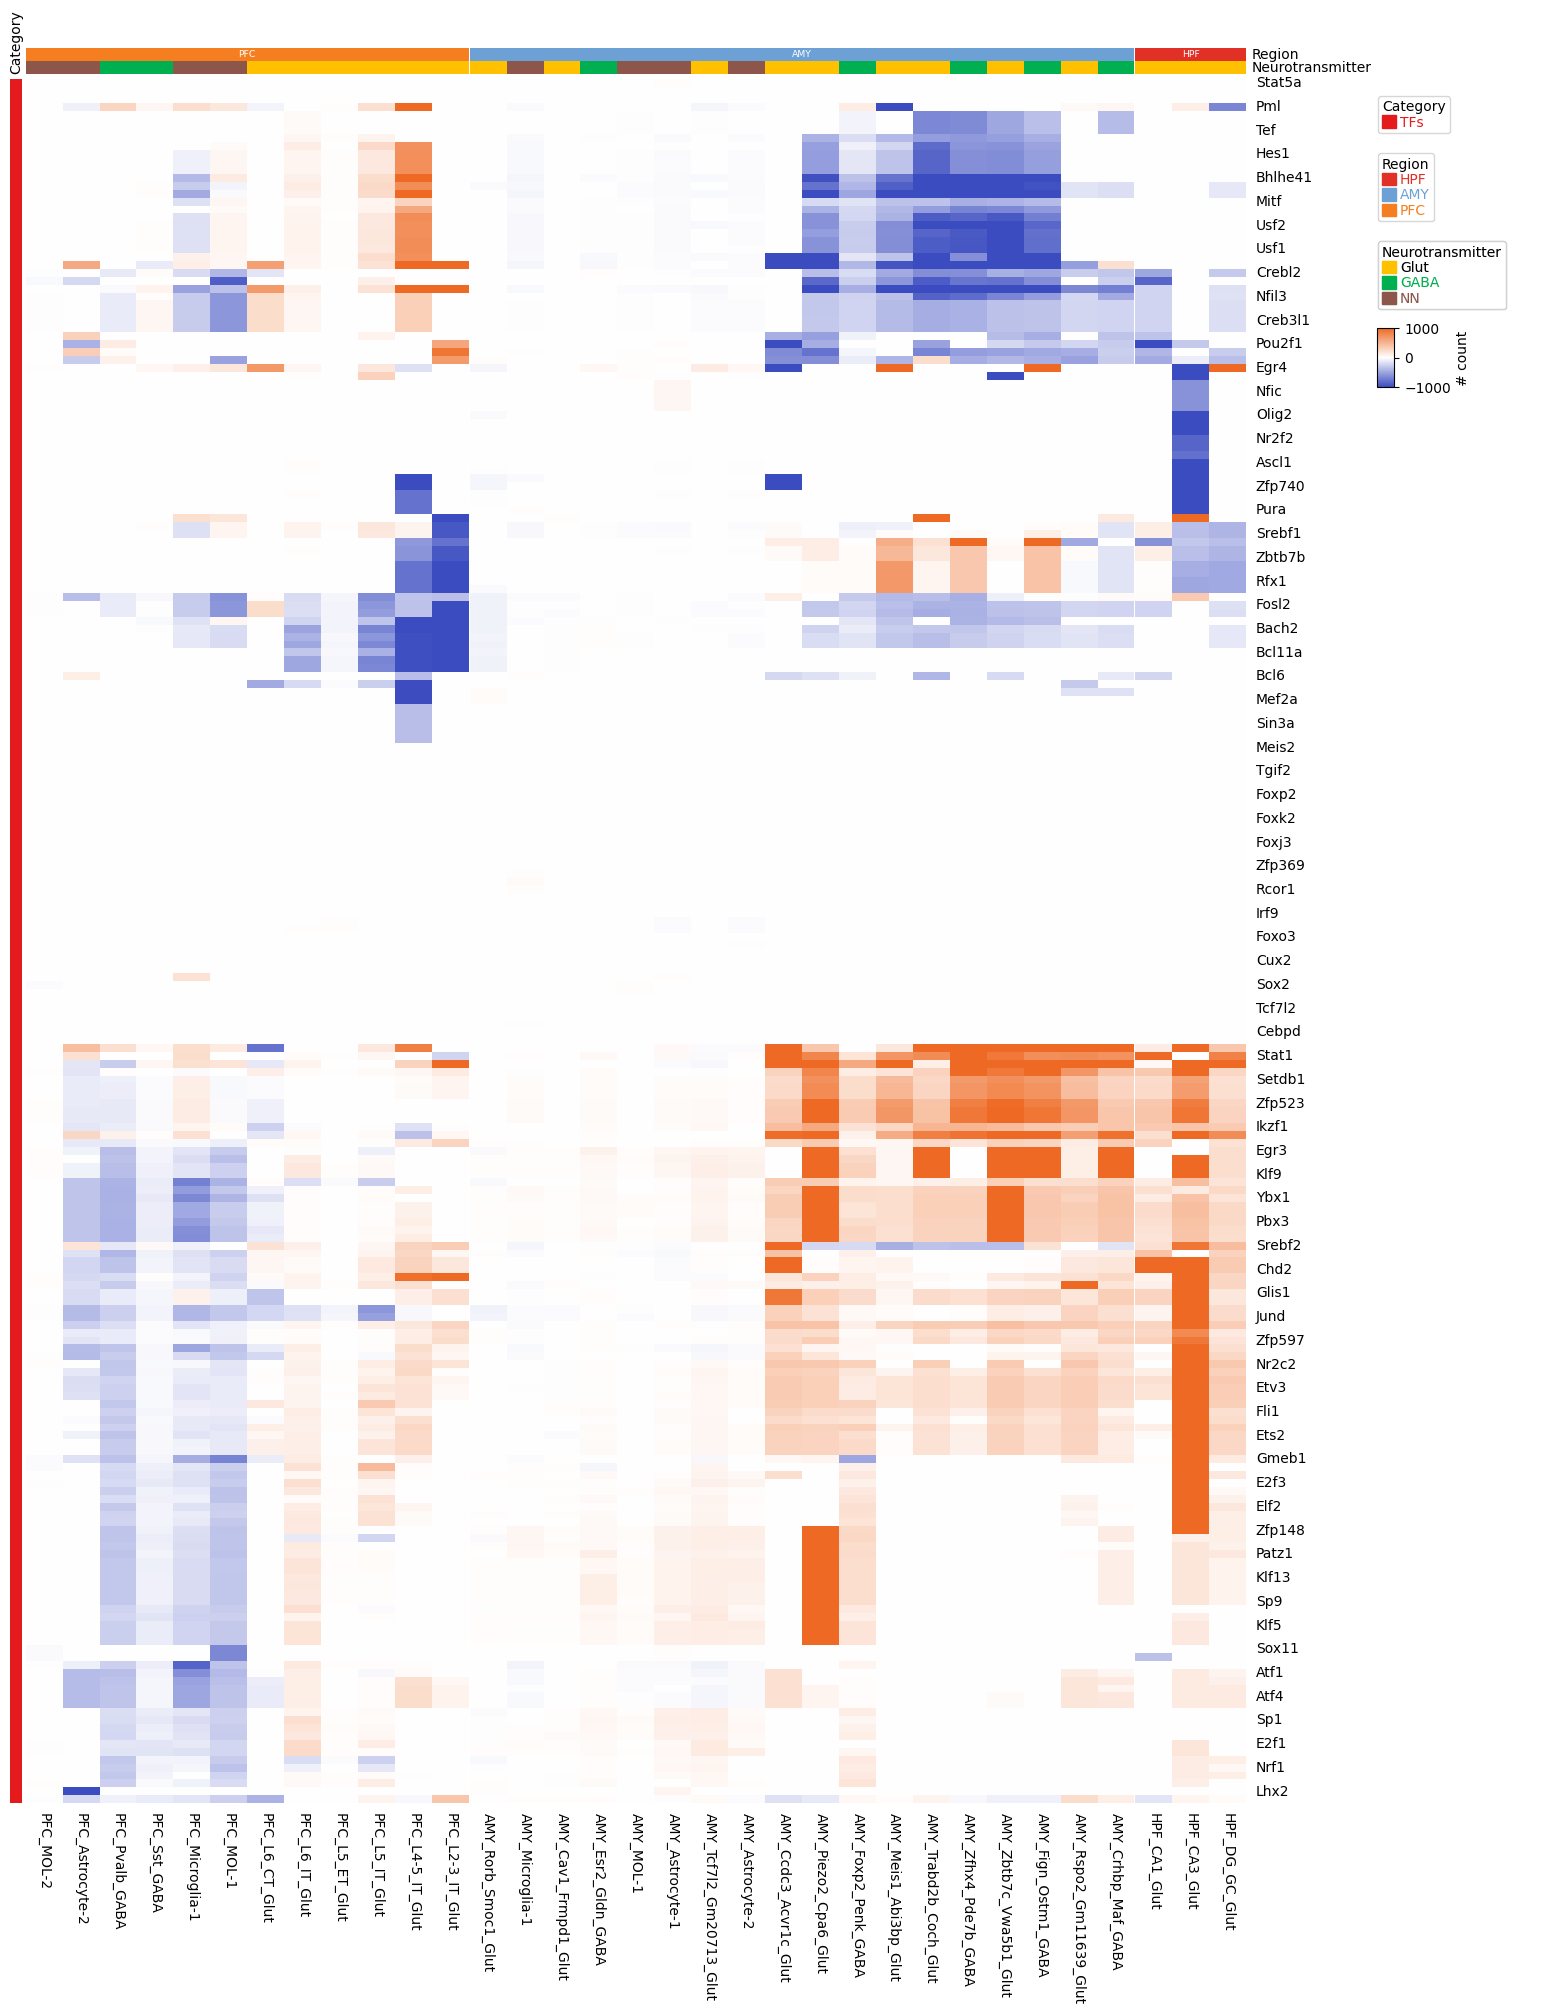

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PyComplexHeatmap as pch
from matplotlib.colors import LinearSegmentedColormap


# ---------------------------------------------------------
# 你的颜色
# ---------------------------------------------------------
region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    "PFC": "#F57E20",
}

nt_colors = {
    "Glut": "#FFC000",
    "GABA": "#00B050",
    "NN":   "#8c564b",
}


# ---------------------------------------------------------
# 主函数：绘制 TF × Region Subclass 热图
# ---------------------------------------------------------
def draw_tf_heatmap(df):
    df = df.copy()
    df['count'] = df['count'].clip(-1000, 1000)
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index="TFs",
        columns="Region Subclass",
        values="count",
        aggfunc="mean"
    ).fillna(0)

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)

    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]

    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TFs", "Category"]]
            .drop_duplicates()
            .set_index("TFs")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )

    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )

    vmin = np.nanmin(mat.values)
    vmax = np.nanmax(mat.values)
    plt.figure(figsize=(16, 20))

    # ============================
    # 7. 绘制 Complex Heatmap
    # ============================
    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=True,
        col_cluster=True,
        cmap=cmap,
        #center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )

    # # # 调整字体
    # if cm.ax_col_names is not None:
    #     for txt in cm.ax_col_names.texts:
    #         txt.set_rotation(90)
    #         txt.set_fontsize(7)

    # if cm.ax_row_names is not None:
    #     for txt in cm.ax_row_names.texts:
    #         txt.set_fontsize(6)

    plt.show()
    return cm
cm = draw_tf_heatmap(df_long_distinct_groupd_selected)

In [121]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Subclass,Sex,Region Subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100456562-100457063,-0.006031,Down,Glut,chr10:100456562-100457063,2.751694e-02
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100487209-100487710,0.068210,Up,Glut,chr10:100487209-100487710,9.867574e-08
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112328.1,chr10:100642797-100643298,-0.014478,Down,Glut,chr10:100642797-100643298,1.490774e-02
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000112713.1,chr10:10107158-10107659,0.030881,Up,Glut,chr10:10107158-10107659,2.347109e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000018909.15,chr7:99535252-99535753,0.001785,Up,GABA,chr7:99535252-99535753,1.977464e-02
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032803.15,chr9:103365644-103366145,0.028069,Up,GABA,chr9:103365644-103366145,4.904168e-02
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,AMY_Npas1_Rgs12_GABA,M,AMY_Npas1_Rgs12_GABA,ENSMUSG00000032470.17,chr9:99436435-99436936,-0.054067,Down,GABA,chr9:99436435-99436936,3.488255e-02
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,PFC_Sst_Chodl_GABA,M,PFC_Sst_Chodl_GABA,ENSMUSG00000021368.15,chr13:43171217-43171718,NaN,Down,GABA,chr13:43171217-43171718,1.842970e-02


In [122]:
df_DAR_Avg = df_DAR.groupby(['Region Subclass','gene_name']).mean().reset_index()

/tmp/ipykernel_2399711/4032396935.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_DAR_Avg = df_DAR.groupby(['Region Subclass','gene_name']).mean().reset_index()


In [123]:
df_DAR_Avg['Direction'] = np.where(df_DAR_Avg['log2FC']>0, 'Up', 'Down')

In [124]:
df_DAR_Avg['Region'] = df_DAR_Avg['Region Subclass'].str.split('_').str[0]

In [125]:
# if GABA in region subclass, then neurotransmitter is GABA, inf Glut in region subclass, set Glut, else set NN

df_DAR_Avg['Neurotransmitter'] = df_DAR_Avg['Region Subclass'].apply(
    lambda x: 'GABA' if 'GABA' in x else ('Glut' if 'Glut' in x else 'NN')
)

In [126]:
df_DAR_Avg['Direction'].value_counts()

Up      121009
Down     74558
Name: Direction, dtype: int64

In [127]:
df_DAR_Avg['Sex'] = 'M'

In [128]:
df_DAR_Avg['Gene'] = df_DAR_Avg['gene_name']

In [129]:
df_DAR_Avg['Subclass'] = df_DAR_Avg['Region Subclass']

In [130]:
df_DAR_Avg.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_avg.csv')